In [2]:
#implementing feed forward neural networks using keras and tensorflow


In [14]:
#importing libraries 
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras import backend as k
from tensorflow.keras.optimizers import SGD


In [8]:
#load the dataset and apply preprocessing- reshaping + normalization 
((x_train,y_train),(x_test,y_test))=mnist.load_data()
x_train= x_train.reshape( x_train.shape[0], 28*28*1 )
x_test= x_test.reshape( x_test.shape[0], 28*28*1 )

x_train= x_train.astype("float32")/255.0
x_test= x_test.astype("float32")/255.0

In [12]:
#encoding- pone hot encoding
LB= LabelBinarizer()
y_train= LB.fit_transform(y_train)
y_test= LB.transform(y_test)

In [16]:
#define the neural network
model= Sequential()
model.add( Dense(256,input_shape=(784,), activation="sigmoid") )
model.add( Dense(128, activation="sigmoid") )
model.add( Dense(10,activation="softmax") )

In [32]:
#training thhe model using sgd
sgd= SGD(0.01)
epochs=100
model.compile(loss="categorical_crossentropy",optimizer=sgd, metrics=["accuracy"])
H=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=epochs, batch_size=128)

Epoch 1/100
469/469 [==============================] - 2s 4ms/step - loss: 2.2781 - accuracy: 0.1966 - val_loss: 2.2417 - val_accuracy: 0.4500
Epoch 2/100
469/469 [==============================] - 2s 4ms/step - loss: 2.2114 - accuracy: 0.3987 - val_loss: 2.1723 - val_accuracy: 0.5332
Epoch 3/100
469/469 [==============================] - 2s 4ms/step - loss: 2.1318 - accuracy: 0.5359 - val_loss: 2.0753 - val_accuracy: 0.5472
Epoch 4/100
469/469 [==============================] - 2s 3ms/step - loss: 2.0161 - accuracy: 0.5994 - val_loss: 1.9344 - val_accuracy: 0.6008
Epoch 5/100
469/469 [==============================] - 2s 3ms/step - loss: 1.8521 - accuracy: 0.6436 - val_loss: 1.7419 - val_accuracy: 0.6708
Epoch 6/100
469/469 [==============================] - 2s 3ms/step - loss: 1.6456 - accuracy: 0.6817 - val_loss: 1.5204 - val_accuracy: 0.7019
Epoch 7/100
469/469 [==============================] - 2s 4ms/step - loss: 1.4274 - accuracy: 0.7140 - val_loss: 1.3085 - val_accuracy: 0.7488

Epoch 58/100
469/469 [==============================] - 2s 5ms/step - loss: 0.3154 - accuracy: 0.9090 - val_loss: 0.3039 - val_accuracy: 0.9132
Epoch 59/100
469/469 [==============================] - 2s 5ms/step - loss: 0.3139 - accuracy: 0.9095 - val_loss: 0.3022 - val_accuracy: 0.9128
Epoch 60/100
469/469 [==============================] - 2s 5ms/step - loss: 0.3122 - accuracy: 0.9098 - val_loss: 0.3014 - val_accuracy: 0.9124
Epoch 61/100
469/469 [==============================] - 2s 5ms/step - loss: 0.3108 - accuracy: 0.9104 - val_loss: 0.2996 - val_accuracy: 0.9134
Epoch 62/100
469/469 [==============================] - 2s 5ms/step - loss: 0.3092 - accuracy: 0.9108 - val_loss: 0.2987 - val_accuracy: 0.9130
Epoch 63/100
469/469 [==============================] - 2s 5ms/step - loss: 0.3078 - accuracy: 0.9112 - val_loss: 0.2967 - val_accuracy: 0.9136
Epoch 64/100
469/469 [==============================] - 2s 5ms/step - loss: 0.3064 - accuracy: 0.9117 - val_loss: 0.2958 - val_accuracy:

In [33]:
#evaluating the model
y_pred= model.predict(x_test, batch_size=128)
print(classification_report(y_test.argmax(axis=1),y_pred.argmax(axis=1),target_names=[ str(x) for x in LB.classes_]))

79/79 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.92      0.91      0.92      1032
           3       0.91      0.90      0.91      1010
           4       0.91      0.94      0.93       982
           5       0.90      0.87      0.88       892
           6       0.93      0.95      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.90      0.89      0.89       974
           9       0.91      0.90      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



[]

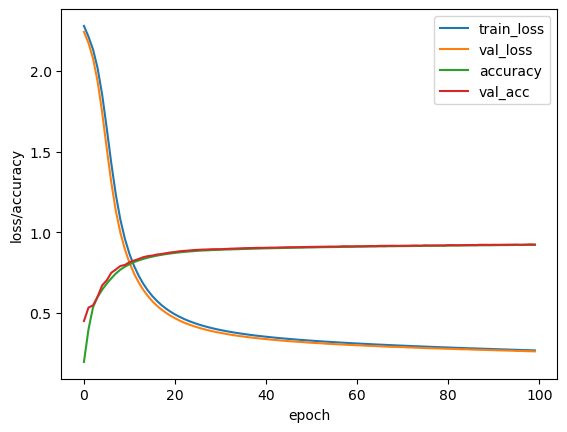

In [38]:
#plotting the model
plt.plot(np.arange(0,100), H.history["loss"] ,label="train_loss")
plt.plot(np.arange(0,100), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0,100), H.history["accuracy"], label="accuracy")
plt.plot(np.arange(0,100), H.history["val_accuracy"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("loss/accuracy")
plt.legend()
plt.plot()